<a href="https://colab.research.google.com/github/asmaslenikova/maslenikova-compling/blob/main/%D0%9C%D0%B0%D1%81%D0%BB%D0%B5%D0%BD%D0%B8%D0%BA%D0%BE%D0%B2%D0%B0_%22convnet_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LXN39D_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LXN39D_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.LXN39D_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


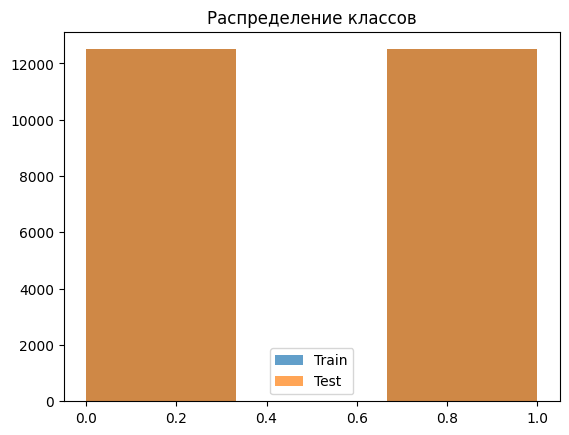

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
# Используйте tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)
# Преобразуйте данные в numpy массивы (x_train, y_train), (x_test, y_test)
x_train = []
y_train = []
for text, label in tfds.as_numpy(train_data):
    x_train.append(text.decode('utf-8'))
    y_train.append(label)

x_test = []
y_test = []
for text, label in tfds.as_numpy(test_data):
    x_test.append(text.decode('utf-8'))
    y_test.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)


print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [2]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
### ВАШ КОД ЗДЕСЬ ###
vectorizer = keras.layers.TextVectorization(
    max_tokens=10000,
    output_sequence_length=200
)
# vectorizer = keras.layers.TextVectorization(max_tokens=..., output_sequence_length=...)

# 4. Адаптируйте векторзатор на тренировочных текстах
### ВАШ КОД ЗДЕСЬ ###
# vectorizer.adapt(...)
vectorizer.adapt(x_train)


# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [4]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
# model = keras.Sequential([...])
model = keras.Sequential([
    keras.layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.build(input_shape=(None, 200))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - Precision: 0.7029 - Recall: 0.5946 - accuracy: 0.6944 - loss: 0.5498 - val_Precision: 0.8176 - val_Recall: 0.9103 - val_accuracy: 0.8518 - val_loss: 0.3336
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - Precision: 0.9209 - Recall: 0.9265 - accuracy: 0.9234 - loss: 0.2017 - val_Precision: 0.8608 - val_Recall: 0.8866 - val_accuracy: 0.8700 - val_loss: 0.3187
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - Precision: 0.9899 - Recall: 0.9904 - accuracy: 0.9902 - loss: 0.0458 - val_Precision: 0.8187 - val_Recall: 0.9257 - val_accuracy: 0.8586 - val_loss: 0.4298
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - Precision: 0.9997 - Recall: 0.9997 - accuracy: 0.9997 - loss: 0.0071 - val_Precision: 0.8849 - val_Recall: 0.8597 - val_accuracy: 0.8724 - val_loss: 0.4533
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - Precision: 0.9999 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0013 - val_Precision: 0.8757 - val_Re

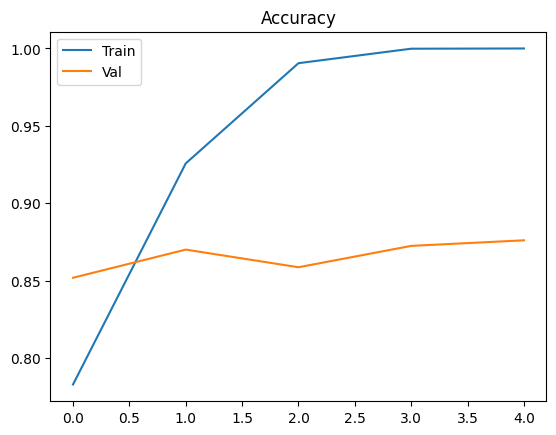

In [5]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
### ВАШ КОД ЗДЕСЬ ###
# model.compile(...)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
### ВАШ КОД ЗДЕСЬ ###
# history = model.fit(...)
history = model.fit(
    x_train_vec,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [9]:
# 10. Оцените модель на тестовых данных
### ВАШ КОД ЗДЕСЬ ###
# test_loss, test_acc, test_prec, test_rec = model.evaluate(...)
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec,
    y_test,
    verbose=0
)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    ### ВАШ КОД ЗДЕСЬ ###
    # pred_prob = model.predict(...)
    # pred_label = "POS" if pred_prob > 0.5 else "NEG"
    pred_prob = model.predict(x_test_vec[i:i+1], verbose=0)
    pred_label = "POS" if pred_prob[0][0] > 0.5 else "NEG"
    print(f"{text[:100]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

Тестовая accuracy: 0.8632
Тестовая precision: 0.8652
Тестовая recall: 0.8604
There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smi... | True: POS | Pred: POS (1.00)
A blackly comic tale of a down-trodden priest, Nazarin showcases the economy that Luis Bunuel was ab... | True: POS | Pred: POS (0.92)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the Spartans, Not another Teen Movie and Another Gay M... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some gravitas to this mawkish, gag-inducing "feel-good" mov... | True: NEG | Pred: NEG (0.00)
As a former Erasmus student I enjoyed this film very much. It was so realistic and funny. It really ... | True: POS | Pred: POS (1.00)
My God, Ryan Gosling has made a lot of deep characters in his career, this is one of his wonderful a... | True: POS | Pred: POS (1.00)
This film just won the best film award at the Cleveland International Film Festival. It's American t... | True: P

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Итоговая точность (accuracy) -- 0.8632, то есть в 86% случаев модель правильно определяет тональность;
2.  Да, переобучение есть. К пятой эпохе Accuracy обучения стало 100%, а Accuracy валидации -- 87%, то есть модель запомнила все примеры обучения.К тому де валидация практически перестала расти.
3. "Every great once in a while, you stumble upon a movie that exceeds even your wildest expectations". Может быть, ошибка связана с тем, что слово "stumble" означает "споткнуться" и может быть рассмотрено как негативное.